## Optimización

en este caso se hará uso de de un dataset de Patologías de colon llamado PathMNIST	convertirda en vectores de (28x28x3) pixeles 2352, siendo este la cantidad de columnas. Consta de:
Training: 89,996 
Validation: 10,004
Test: 7,180
links del dataset:
- https://zenodo.org/records/10519652
- https://medmnist.com/
- https://github.com/MedMNIST/MedMNIST

Cargamos los datos a la variables correspondientes

In [27]:
import numpy as np

data = np.load("pathmnist.npz")

train_images = data["train_images"]   
train_labels = data["train_labels"].squeeze()  

val_images   = data["val_images"]     
val_labels   = data["val_labels"].squeeze()

test_images  = data["test_images"]    
test_labels  = data["test_labels"].squeeze()

X_train, y_train = train_images[:89996], train_labels[:89996]
X_val,   y_val   = val_images, val_labels
X_test,  y_test  = test_images, test_labels
X_subset, y_subset = train_images[:5000], train_labels[:5000]

print(X_train.shape, X_val.shape, X_test.shape, X_subset.shape)


(89996, 28, 28, 3) (10004, 28, 28, 3) (7180, 28, 28, 3) (5000, 28, 28, 3)


#### Preparación datos para entrenamiento de modelo 28x28x3 

ademas de normalización para trabajar con imagenes, conversión a tensores (como trabaja pytorch), dataloaders y separación en conjuntos

In [28]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X / 255.).float().cuda().view(-1, 28*28*3)
        self.Y = torch.from_numpy(Y).long().cuda()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(89996, 10004)

In [29]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=28*28*3, H=100, D_out=9):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

## Optimizadores

#### Descenso de Gradiente Estocástico (SGD)

In [30]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.26191 en epoch 1
Mejor modelo guardado con acc 0.28991 en epoch 2
Mejor modelo guardado con acc 0.29909 en epoch 3
Mejor modelo guardado con acc 0.31873 en epoch 4
Mejor modelo guardado con acc 0.34855 en epoch 6
Mejor modelo guardado con acc 0.40545 en epoch 7
Mejor modelo guardado con acc 0.41173 en epoch 8
Mejor modelo guardado con acc 0.41364 en epoch 9
Mejor modelo guardado con acc 0.42355 en epoch 10
Epoch 10/100 loss 1.62271 acc 0.39625 val_loss 1.59359 val_acc 0.42355
Mejor modelo guardado con acc 0.43127 en epoch 11
Mejor modelo guardado con acc 0.44127 en epoch 13
Mejor modelo guardado con acc 0.44491 en epoch 14
Mejor modelo guardado con acc 0.46682 en epoch 15
Mejor modelo guardado con acc 0.46727 en epoch 17
Mejor modelo guardado con acc 0.47000 en epoch 18
Mejor modelo guardado con acc 0.47809 en epoch 19
Epoch 20/100 loss 1.48799 acc 0.46004 val_loss 1.48985 val_acc 0.46109
Mejor modelo guardado con acc 0.48564 en epoch 21
Mejor modelo gua

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\787039971.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


#### Momentum

In [31]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.37973 en epoch 1
Mejor modelo guardado con acc 0.46673 en epoch 2
Mejor modelo guardado con acc 0.47682 en epoch 4
Mejor modelo guardado con acc 0.51109 en epoch 5
Mejor modelo guardado con acc 0.52391 en epoch 6
Mejor modelo guardado con acc 0.54809 en epoch 7
Mejor modelo guardado con acc 0.56136 en epoch 9
Epoch 10/100 loss 1.21683 acc 0.53932 val_loss 1.18676 val_acc 0.56100
Mejor modelo guardado con acc 0.59155 en epoch 13
Mejor modelo guardado con acc 0.62200 en epoch 18
Mejor modelo guardado con acc 0.62545 en epoch 20
Epoch 20/100 loss 1.06850 acc 0.59163 val_loss 1.10113 val_acc 0.62545
Mejor modelo guardado con acc 0.62900 en epoch 23
Mejor modelo guardado con acc 0.63173 en epoch 25
Mejor modelo guardado con acc 0.63236 en epoch 27
Mejor modelo guardado con acc 0.64300 en epoch 29
Epoch 30/100 loss 1.00245 acc 0.61484 val_loss 1.12176 val_acc 0.61018
Mejor modelo guardado con acc 0.64473 en epoch 32
Epoch 40/100 loss 0.95536 acc 0.63181 val_lo

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\787039971.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


#### RMSProp

In [32]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.43855 en epoch 1
Mejor modelo guardado con acc 0.46909 en epoch 2
Mejor modelo guardado con acc 0.53236 en epoch 3
Mejor modelo guardado con acc 0.53418 en epoch 4
Mejor modelo guardado con acc 0.57345 en epoch 10
Epoch 10/100 loss 1.21298 acc 0.53799 val_loss 1.15908 val_acc 0.57345
Mejor modelo guardado con acc 0.58264 en epoch 13
Mejor modelo guardado con acc 0.58364 en epoch 15
Epoch 20/100 loss 1.14438 acc 0.56236 val_loss 1.14627 val_acc 0.55427
Mejor modelo guardado con acc 0.59491 en epoch 22
Mejor modelo guardado con acc 0.59736 en epoch 28
Epoch 30/100 loss 1.11954 acc 0.57153 val_loss 1.29743 val_acc 0.52982
Mejor modelo guardado con acc 0.60145 en epoch 31
Mejor modelo guardado con acc 0.60282 en epoch 37
Epoch 40/100 loss 1.10220 acc 0.57927 val_loss 1.45889 val_acc 0.45082
Mejor modelo guardado con acc 0.61236 en epoch 45
Mejor modelo guardado con acc 0.61382 en epoch 47
Epoch 50/100 loss 1.08788 acc 0.58300 val_loss 1.04715 val_acc 0.60609

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\787039971.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


#### Adam

In [33]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.48782 en epoch 1
Mejor modelo guardado con acc 0.53273 en epoch 2
Mejor modelo guardado con acc 0.53536 en epoch 3
Mejor modelo guardado con acc 0.55855 en epoch 4
Mejor modelo guardado con acc 0.57900 en epoch 5
Mejor modelo guardado con acc 0.58700 en epoch 7
Mejor modelo guardado con acc 0.59573 en epoch 8
Mejor modelo guardado con acc 0.61091 en epoch 9
Epoch 10/100 loss 1.07295 acc 0.58447 val_loss 1.07102 val_acc 0.58836
Mejor modelo guardado con acc 0.62055 en epoch 12
Mejor modelo guardado con acc 0.63773 en epoch 16
Epoch 20/100 loss 0.98578 acc 0.61891 val_loss 1.03842 val_acc 0.61973
Mejor modelo guardado con acc 0.63845 en epoch 21
Mejor modelo guardado con acc 0.64273 en epoch 24
Mejor modelo guardado con acc 0.64745 en epoch 25
Epoch 30/100 loss 0.97056 acc 0.62300 val_loss 0.98282 val_acc 0.61836
Epoch 40/100 loss 0.95857 acc 0.62839 val_loss 0.94739 val_acc 0.64309
Mejor modelo guardado con acc 0.64945 en epoch 44
Mejor modelo guardado co

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\787039971.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


##### Generamos una gráfica comparativa entre los optimizadores

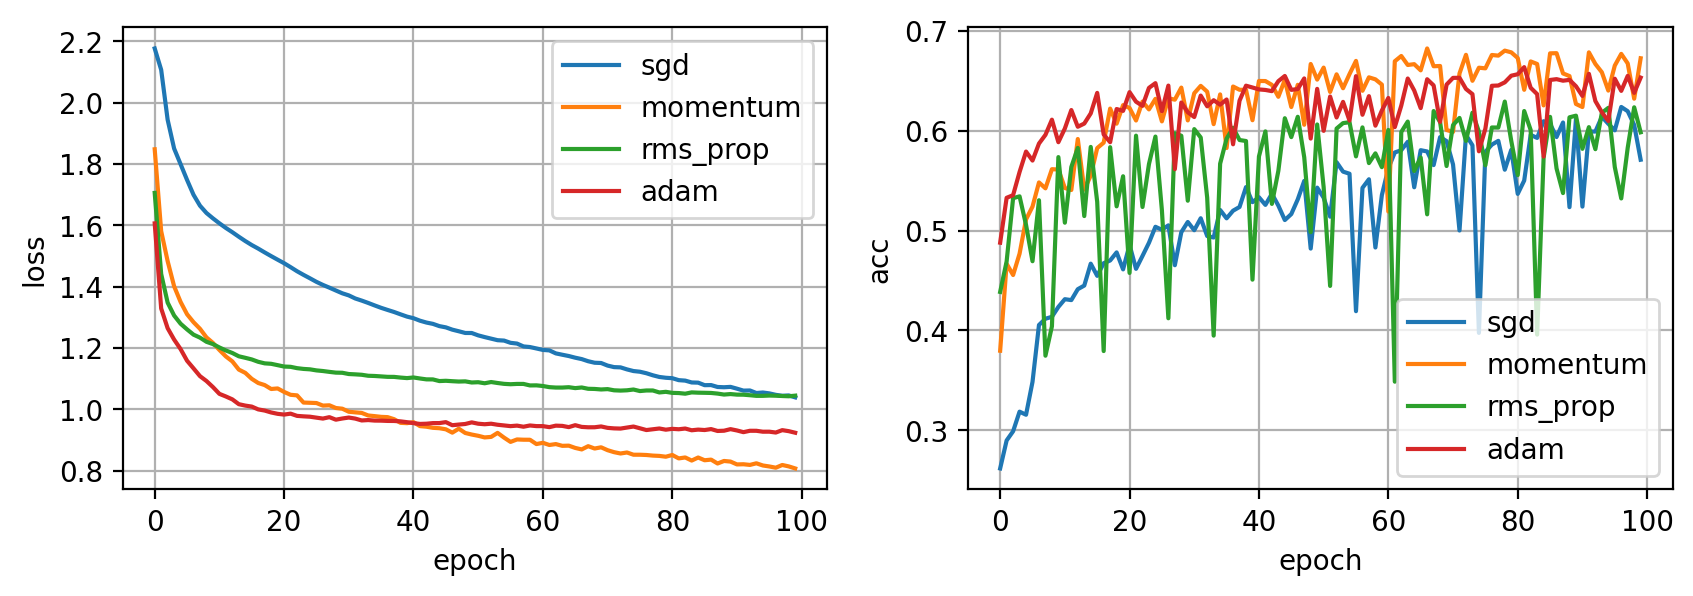

In [34]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Los optimizadores Adam y Momentum son claramente los más eficientes en este caso. Aprenden rápido, bajan la pérdida de forma estable y logran una precisión alta sin tanto esfuerzo. En cambio, SGD se queda atrás: es más lento y menos preciso. RMSprop está en un punto medio, pero tampoco alcanza el rendimiento de los otros dos.

## *Learning Rate Scheduling*

Una forma muy útil de acelerar el entrenamiento de una red neuronal es ajustar el *learning rate* a lo largo del proceso, en vez de dejarlo fijo. Al principio, un *learning rate* alto ayuda a que el modelo aprenda rápido, pero puede hacer que no llegue al mejor resultado posible porque se queda "rebotando" cerca del óptimo. En cambio, un *learning rate* bajo permite afinar mucho más, aunque el entrenamiento se vuelve más lento.

In [35]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

#### StepLR

Cada 10 epoch multiplicamos el lr*=0.1

In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=40)

Mejor modelo guardado con acc 0.44955 en epoch 1
Mejor modelo guardado con acc 0.47127 en epoch 3
Mejor modelo guardado con acc 0.47727 en epoch 4
Mejor modelo guardado con acc 0.47982 en epoch 6
Mejor modelo guardado con acc 0.48191 en epoch 7
Mejor modelo guardado con acc 0.50818 en epoch 8
Mejor modelo guardado con acc 0.52264 en epoch 9
Mejor modelo guardado con acc 0.52273 en epoch 10
Epoch 10/40 loss 1.36084 acc 0.48389 val_loss 1.32010 val_acc 0.52273 lr 0.01000
Mejor modelo guardado con acc 0.56464 en epoch 11
Mejor modelo guardado con acc 0.56864 en epoch 12
Mejor modelo guardado con acc 0.58936 en epoch 13
Mejor modelo guardado con acc 0.59655 en epoch 16
Epoch 20/40 loss 1.09187 acc 0.57959 val_loss 1.06353 val_acc 0.59445 lr 0.00100
Mejor modelo guardado con acc 0.59955 en epoch 21
Mejor modelo guardado con acc 0.61282 en epoch 22
Mejor modelo guardado con acc 0.61500 en epoch 24
Mejor modelo guardado con acc 0.61836 en epoch 27
Epoch 30/40 loss 1.01658 acc 0.60994 val_loss

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


#### CyclicLR

El lr amuenta por 5 epoch y luego disminuye, para explorar de mejor manera

In [37]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# aumenta el lr por 5 epochs, luego decrece
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=40)

Mejor modelo guardado con acc 0.26918 en epoch 1
Mejor modelo guardado con acc 0.44091 en epoch 2
Mejor modelo guardado con acc 0.47936 en epoch 3
Mejor modelo guardado con acc 0.51845 en epoch 4
Mejor modelo guardado con acc 0.52918 en epoch 6
Mejor modelo guardado con acc 0.54282 en epoch 7
Mejor modelo guardado con acc 0.54936 en epoch 9
Epoch 10/40 loss 1.23639 acc 0.52992 val_loss 1.25379 val_acc 0.53682 lr 0.00842
Mejor modelo guardado con acc 0.55918 en epoch 12
Mejor modelo guardado con acc 0.59518 en epoch 13
Mejor modelo guardado con acc 0.60127 en epoch 15
Epoch 20/40 loss 1.06867 acc 0.59039 val_loss 1.37670 val_acc 0.53600 lr 0.00446
Mejor modelo guardado con acc 0.63209 en epoch 21
Mejor modelo guardado con acc 0.64855 en epoch 27
Mejor modelo guardado con acc 0.65600 en epoch 29
Mejor modelo guardado con acc 0.65927 en epoch 30
Epoch 30/40 loss 0.88478 acc 0.65901 val_loss 0.95749 val_acc 0.65927 lr 0.00050
Mejor modelo guardado con acc 0.66482 en epoch 31
Epoch 40/40 lo

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


##### Verificamos las gráficas comparativas

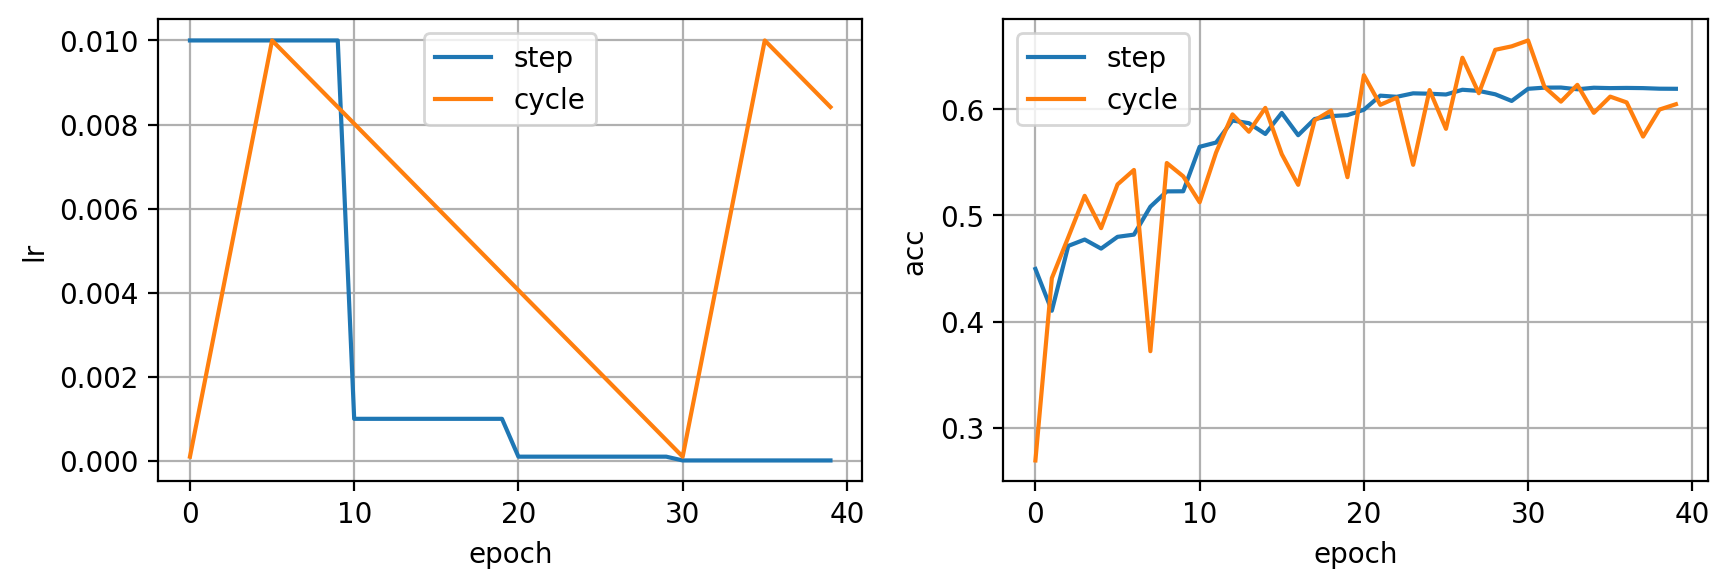

In [38]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

El método step baja la tasa de golpe cada cierto tiempo, mientras que cycle la sube y baja en ciclos. Al final, cycle ayudó al modelo a aprender mejor y lograr mayor precisión, aunque con más variaciones

## Normalización

Normalizar los datos es clave para entrenar redes neuronales más rápido y de forma estable. Ya vimos que dividir las imágenes por 255 ayuda a que los valores estén entre 0 y 1. Otra opción común es ajustar las imágenes para que tengan media 0 y desviación estándar 1, usando el promedio y la desviación estándar del propio dataset.

In [39]:
mean = (X_train / 255).mean(axis=(0, 1, 2))
std  = (X_train / 255).std(axis=(0, 1, 2))
print("Mean:", mean)
print("Std:", std)


Mean: [0.740545   0.53298219 0.70582885]
Std: [0.12368222 0.17676253 0.12443067]


In [40]:
X_train_norm  = ((X_train  / 255.) - mean) / std
X_val_norm    = ((X_val    / 255.) - mean) / std
X_test_norm   = ((X_test   / 255.) - mean) / std
X_subset_norm = ((X_subset / 255.) - mean) / std

X_train_norm.shape, X_val_norm.shape, X_test_norm.shape, X_subset_norm.shape


((89996, 28, 28, 3), (10004, 28, 28, 3), (7180, 28, 28, 3), (5000, 28, 28, 3))

##### Creamos e conjunto de Dataset y Dataloaders

In [41]:
dataset_norm = {
    'train': Dataset(X_train_norm, y_train),
    'val': Dataset(X_val_norm, y_val),
}

# DataLoaders
dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset_norm['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset_norm['val'], batch_size=1000, shuffle=False)
}

len(dataset_norm['train']), len(dataset_norm['val'])


(89996, 10004)

##### entrenamos nuestro modelo en base a los datos normalizados

In [42]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.13018 en epoch 1
Mejor modelo guardado con acc 0.13509 en epoch 3
Mejor modelo guardado con acc 0.34364 en epoch 4
Mejor modelo guardado con acc 0.34518 en epoch 5
Mejor modelo guardado con acc 0.35136 en epoch 6
Mejor modelo guardado con acc 0.35627 en epoch 7
Mejor modelo guardado con acc 0.36064 en epoch 8
Mejor modelo guardado con acc 0.36200 en epoch 9
Mejor modelo guardado con acc 0.36309 en epoch 10
Epoch 10/100 loss 1.62289 acc 0.36549 val_loss 1.61693 val_acc 0.36309 lr 0.00100
Mejor modelo guardado con acc 0.41645 en epoch 11
Mejor modelo guardado con acc 0.41827 en epoch 13
Mejor modelo guardado con acc 0.42909 en epoch 14
Mejor modelo guardado con acc 0.43355 en epoch 15
Mejor modelo guardado con acc 0.46036 en epoch 16
Mejor modelo guardado con acc 0.49945 en epoch 17
Mejor modelo guardado con acc 0.53827 en epoch 18
Mejor modelo guardado con acc 0.55436 en epoch 19
Mejor modelo guardado con acc 0.56055 en epoch 20
Epoch 20/100 loss 1.27444 

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


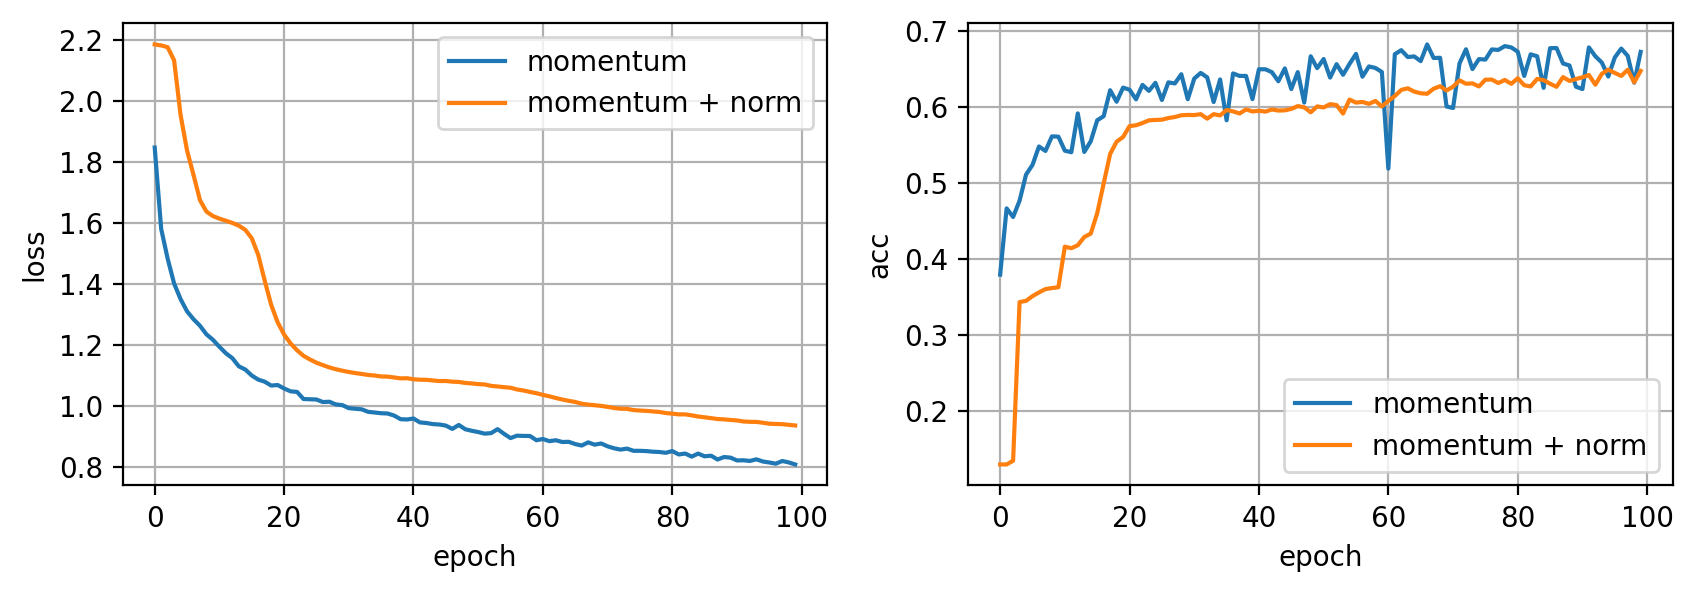

In [43]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

### *Batch Normalization*

Usar batch norm ayuda bastante, normaliza las entradas para que el modelo aprenda más rápido y con más estabilidad además, ajusta esos valores para que la red los entienda mejor y clasifique con más precisión

In [44]:
def build_model(D_in=28*28*3, H=100, D_out=9):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [45]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.61291 en epoch 1
Mejor modelo guardado con acc 0.64873 en epoch 6
Mejor modelo guardado con acc 0.67336 en epoch 10
Epoch 10/100 loss 0.76482 acc 0.70927 val_loss 0.91297 val_acc 0.67336 lr 0.00100
Epoch 20/100 loss 0.64212 acc 0.75646 val_loss 0.93695 val_acc 0.64364 lr 0.00100
Epoch 30/100 loss 0.56045 acc 0.79080 val_loss 1.20124 val_acc 0.61309 lr 0.00100
Epoch 40/100 loss 0.49892 acc 0.81411 val_loss 1.71312 val_acc 0.50018 lr 0.00100
Epoch 50/100 loss 0.44860 acc 0.83513 val_loss 1.31473 val_acc 0.58945 lr 0.00100
Epoch 60/100 loss 0.40604 acc 0.85031 val_loss 1.27665 val_acc 0.63618 lr 0.00100
Epoch 70/100 loss 0.37740 acc 0.86029 val_loss 1.77962 val_acc 0.56809 lr 0.00100
Epoch 80/100 loss 0.35713 acc 0.86835 val_loss 1.64595 val_acc 0.61973 lr 0.00100
Epoch 90/100 loss 0.33304 acc 0.87808 val_loss 1.63403 val_acc 0.56827 lr 0.00100
Epoch 100/100 loss 0.31735 acc 0.88411 val_loss 1.61175 val_acc 0.58818 lr 0.00100


C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


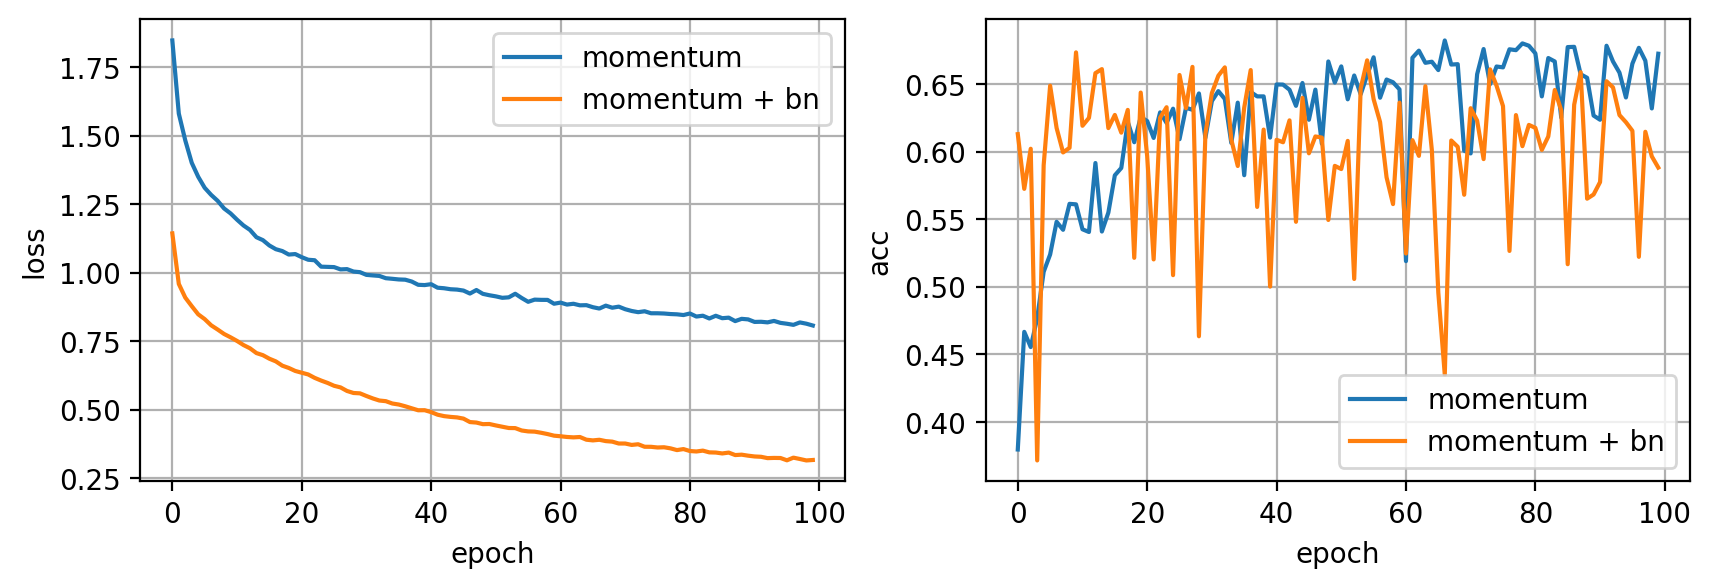

In [46]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

### Regularización

#### Regularización L2

La regularización L2 es una forma sencilla de evitar que los pesos de la red se disparen, lo que hace es agregar una penalización en la función de pérdida para mantenerlos bajo control, generalmente se prueba con valores de α entre 0.001 y 0.01.

In [47]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
hist = fit(model, dataloader, optimizer, weight_decay=0.01)

Mejor modelo guardado con acc 0.26718 en epoch 1
Mejor modelo guardado con acc 0.50564 en epoch 4
Mejor modelo guardado con acc 0.51700 en epoch 9
Epoch 10/100 loss 1.08580 acc 0.59250 val_loss 2.56395 val_acc 0.31536 lr 0.00100
Epoch 20/100 loss 1.08295 acc 0.59628 val_loss 2.64719 val_acc 0.20564 lr 0.00100
Epoch 30/100 loss 1.08308 acc 0.59469 val_loss 1.84013 val_acc 0.37536 lr 0.00100
Mejor modelo guardado con acc 0.52927 en epoch 33
Mejor modelo guardado con acc 0.54982 en epoch 34
Mejor modelo guardado con acc 0.57155 en epoch 36
Epoch 40/100 loss 1.08369 acc 0.59463 val_loss 1.35387 val_acc 0.48100 lr 0.00100
Epoch 50/100 loss 1.08200 acc 0.59611 val_loss 1.24326 val_acc 0.54709 lr 0.00100
Epoch 60/100 loss 1.08187 acc 0.59503 val_loss 1.80887 val_acc 0.36991 lr 0.00100
Epoch 70/100 loss 1.08254 acc 0.59587 val_loss 3.83168 val_acc 0.23682 lr 0.00100
Epoch 80/100 loss 1.08351 acc 0.59490 val_loss 1.33723 val_acc 0.51055 lr 0.00100
Mejor modelo guardado con acc 0.58100 en epoch 

C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


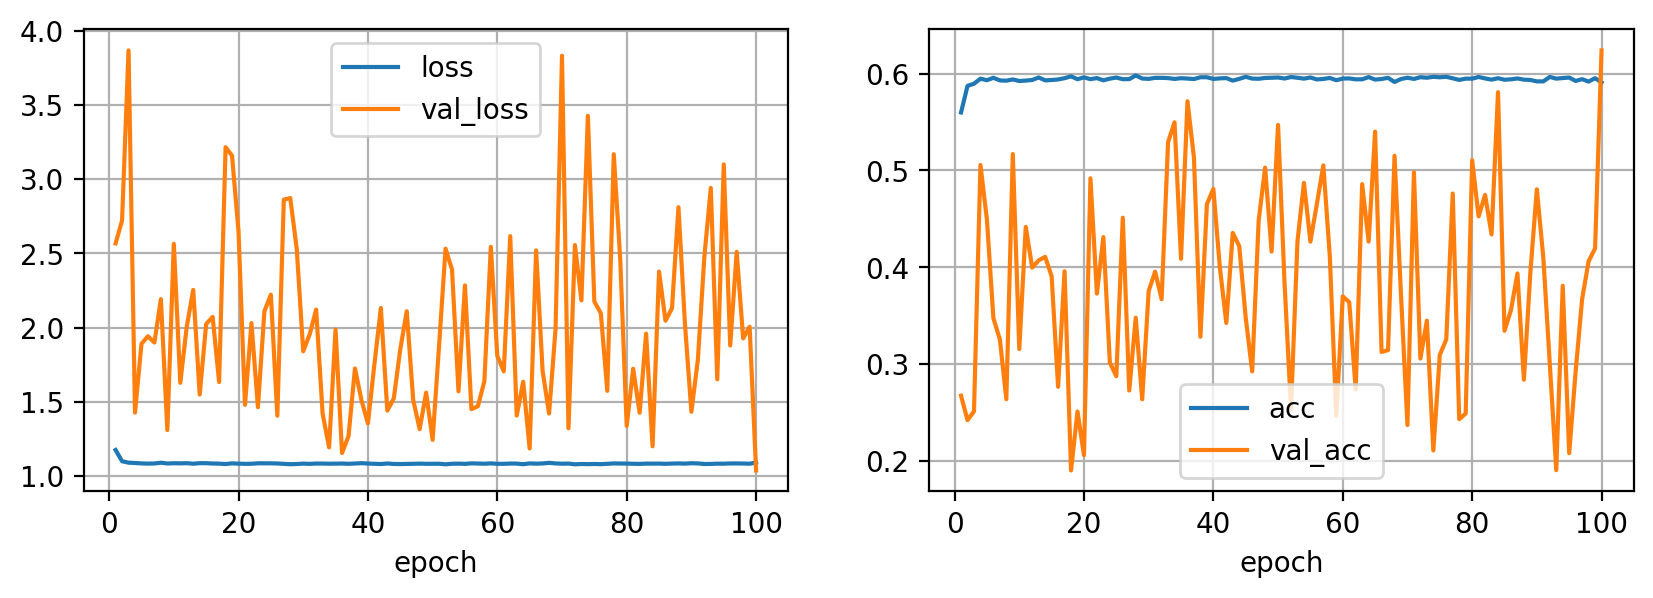

In [48]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

#### Early Stopping 

El early stopping es una forma práctica de regularizar el modelo, guarda los mejores pesos durante el entrenamiento y los recupera al final, en lugar de quedarse con los últimos además, si las métricas no mejoran tras varias épocas seguidas, se puede detener el entrenamiento antes, ahorrando tiempo y recursos.

In [49]:
def fit(model, dataloader, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [50]:
model = build_model()
hist = fit(model, dataloader, early_stopping=20)

Mejor modelo guardado con acc 0.23600 en epoch 1
Mejor modelo guardado con acc 0.42764 en epoch 2
Mejor modelo guardado con acc 0.56709 en epoch 3
Mejor modelo guardado con acc 0.59545 en epoch 5
Mejor modelo guardado con acc 0.61236 en epoch 6
Mejor modelo guardado con acc 0.61836 en epoch 7
Mejor modelo guardado con acc 0.63709 en epoch 10
Epoch 10/100 loss 0.73060 acc 0.71811 val_loss 0.94498 val_acc 0.63709
Epoch 20/100 loss 0.62027 acc 0.76441 val_loss 3.15931 val_acc 0.27209
Mejor modelo guardado con acc 0.65473 en epoch 24
Epoch 30/100 loss 0.54033 acc 0.79675 val_loss 2.64028 val_acc 0.45164
Epoch 40/100 loss 0.48776 acc 0.81674 val_loss 1.73232 val_acc 0.51182
Entrenamiento detenido en epoch 44 por no mejorar en 20 epochs seguidas


C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1910897778.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


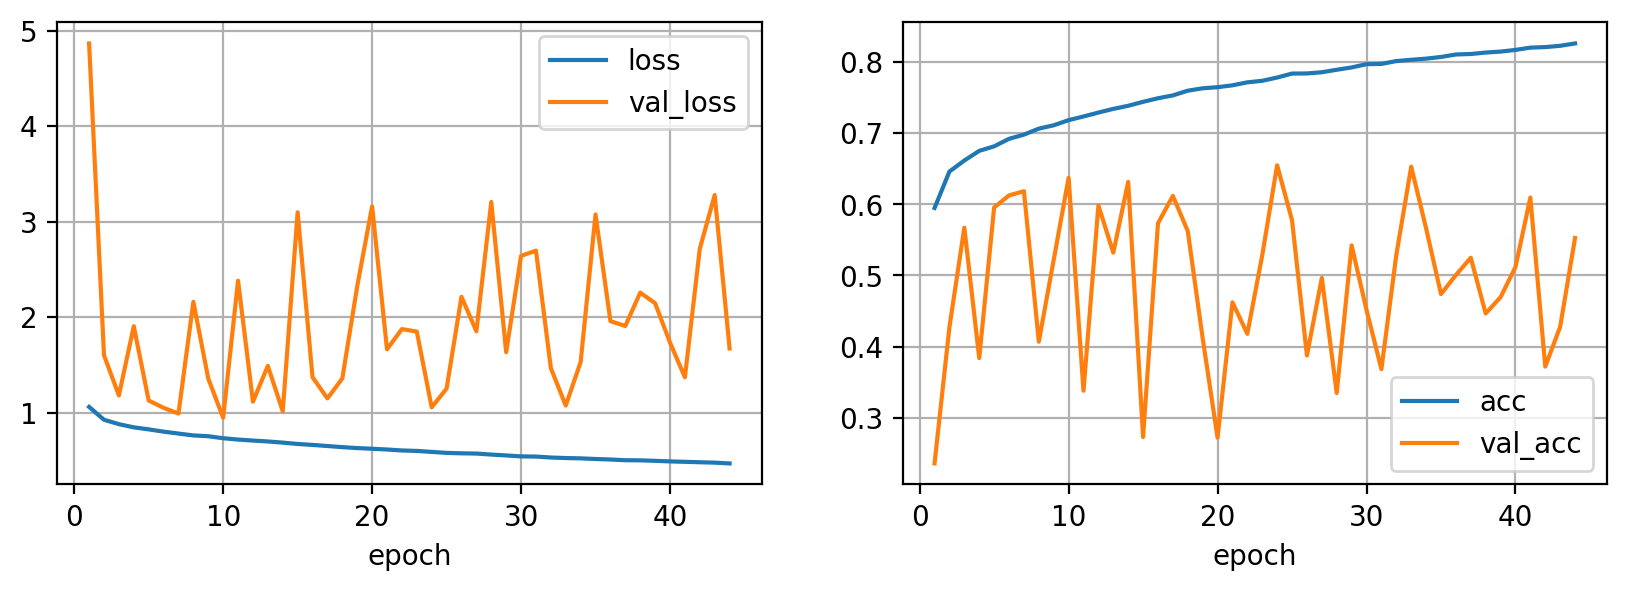

In [51]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

#### Dropout

Dropout ayuda a evitar el overfitting apagando neuronas al azar mientras entrenamos. Así el modelo no se vuelve dependiente de rutas específicas y aprende de forma más flexible

In [52]:
def build_model(D_in=28*28*3, H=100, D_out=9, p=0):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [53]:
model = build_model(p=0.5)
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.13018 en epoch 1
Mejor modelo guardado con acc 0.13027 en epoch 4
Mejor modelo guardado con acc 0.31082 en epoch 6
Mejor modelo guardado con acc 0.31164 en epoch 7
Mejor modelo guardado con acc 0.34700 en epoch 8
Epoch 10/100 loss 2.15059 acc 0.15862 val_loss 2.15523 val_acc 0.13018
Epoch 20/100 loss 2.12088 acc 0.15919 val_loss 2.09288 val_acc 0.13018
Epoch 30/100 loss 2.14427 acc 0.15558 val_loss 2.08079 val_acc 0.16809
Epoch 40/100 loss 2.13555 acc 0.15391 val_loss 2.02320 val_acc 0.17245
Epoch 50/100 loss 2.12988 acc 0.15418 val_loss 2.00591 val_acc 0.27845
Epoch 60/100 loss 2.13403 acc 0.15410 val_loss 2.05206 val_acc 0.13018
Epoch 70/100 loss 2.13168 acc 0.15287 val_loss 2.03437 val_acc 0.13045
Epoch 80/100 loss 2.13174 acc 0.15090 val_loss 2.40777 val_acc 0.13327
Epoch 90/100 loss 2.12937 acc 0.15156 val_loss 2.02241 val_acc 0.18136
Epoch 100/100 loss 2.12987 acc 0.15325 val_loss 2.03891 val_acc 0.20064


C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_14108\1910897778.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


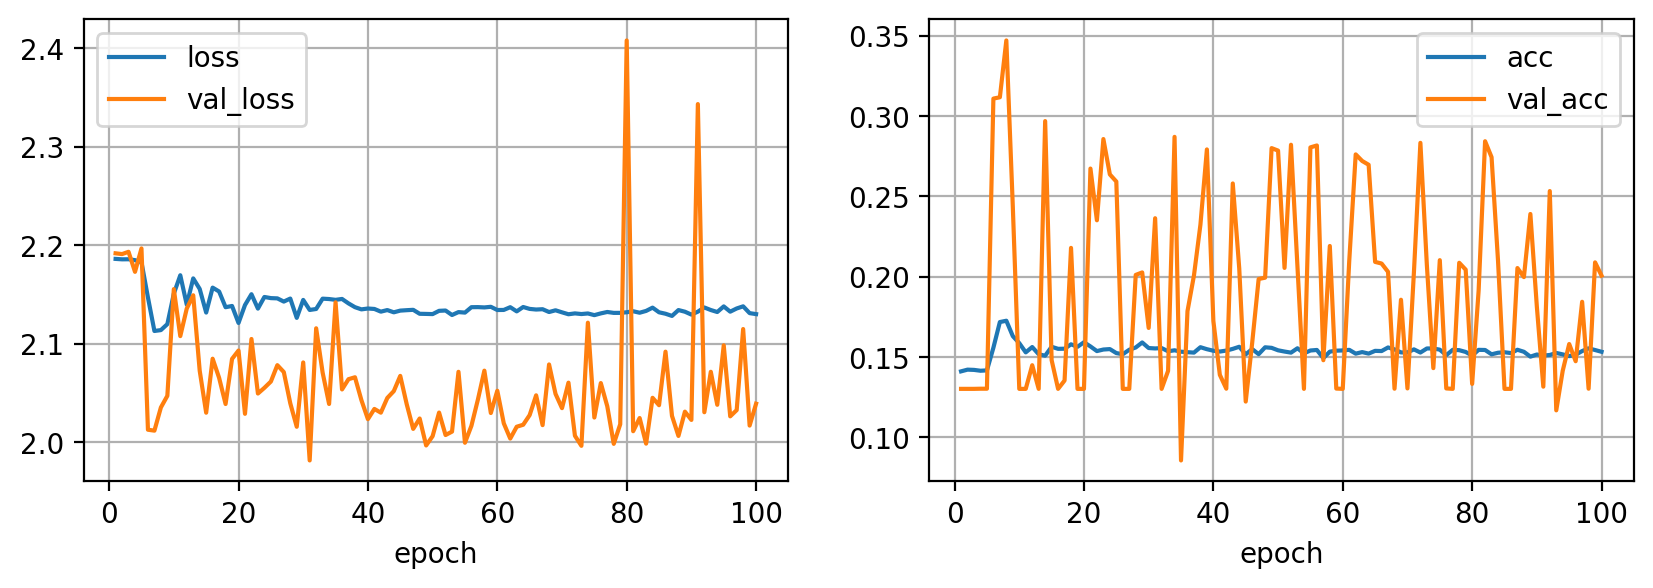

In [54]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()